In [1]:
import sys, os

sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import np, pd, plt, save_figure, cream, bordeaux, navy
from matplotlib.colors import LinearSegmentedColormap

FIG_DIR = "../figures/evaluation/anonymity"
os.makedirs(FIG_DIR, exist_ok=True)

DIRICHLET_ALPHAS = [0.1, 0.5, 1.0, 10.0]
PARTIAL_UPDATE_VALS = [0.10, 0.25, 0.50, 0.75, 1.00]
OVERLAY_PEERS_N = 8

In [2]:
GRID_CSV = "../metrics/anon_content_attack/grid.csv"

attribute = np.full((len(DIRICHLET_ALPHAS), len(PARTIAL_UPDATE_VALS)), np.nan)
track = np.full((len(DIRICHLET_ALPHAS), len(PARTIAL_UPDATE_VALS)), np.nan)

grid = pd.read_csv(GRID_CSV)

for alpha_index, alpha in enumerate(DIRICHLET_ALPHAS):

    for ratio_index, ratio in enumerate(PARTIAL_UPDATE_VALS):

        cell_rows = grid[(grid.alpha == alpha) & (grid.r == ratio)]

        attribute[alpha_index, ratio_index] = cell_rows.attribute.mean()
        track[alpha_index, ratio_index] = cell_rows.track.mean()

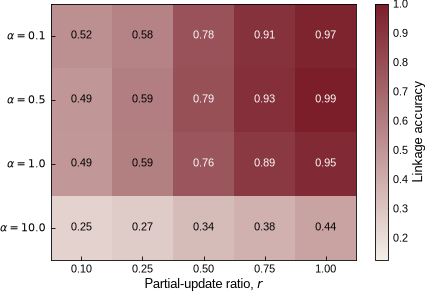

In [3]:
baseline_chance = 1.0 / OVERLAY_PEERS_N

cmap_attribute = LinearSegmentedColormap.from_list("cream_bordeaux", [cream, bordeaux])

fig, ax = plt.subplots(figsize=(4.4, 3.0))

im = ax.imshow(attribute, cmap=cmap_attribute, vmin=baseline_chance, vmax=1.0, aspect="auto", origin="upper")

ax.set_xticks(range(len(PARTIAL_UPDATE_VALS)))
ax.set_xticklabels([f"{ratio:.2f}" for ratio in PARTIAL_UPDATE_VALS])
ax.set_yticks(range(len(DIRICHLET_ALPHAS)))
ax.set_yticklabels([rf"$\alpha={alpha}$" for alpha in DIRICHLET_ALPHAS])
ax.set_xlabel(r"Partial-update ratio, $r$")

for row in range(attribute.shape[0]):

    for col in range(attribute.shape[1]):

        accuracy = attribute[row, col]

        if not np.isnan(accuracy):
            text_color = "white" if (accuracy - baseline_chance) / (1.0 - baseline_chance) > 0.6 else "black"
            ax.text(col, row, f"{accuracy:.2f}", ha="center", va="center", fontsize=8, color=text_color)

fig.colorbar(im, ax=ax, label="Linkage accuracy")
fig.tight_layout()

save_figure(fig, f"{FIG_DIR}/content_attack_attribute_heatmap.pdf")
plt.show()

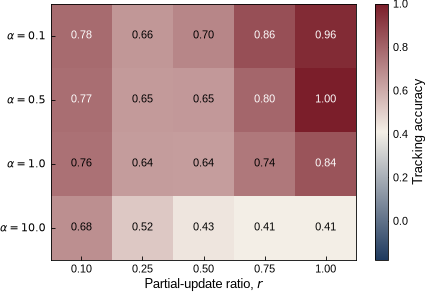

In [4]:
anchor_track = track[DIRICHLET_ALPHAS.index(10.0), PARTIAL_UPDATE_VALS.index(1.0)]

track_range = float(np.nanmax(np.abs(track - anchor_track)))

cmap_track = LinearSegmentedColormap.from_list("navy_cream_bordeaux", [navy, cream, bordeaux])

fig, ax = plt.subplots(figsize=(4.4, 3.0))

im = ax.imshow(track, cmap=cmap_track, vmin=anchor_track - track_range, vmax=anchor_track + track_range, aspect="auto", origin="upper")

ax.set_xticks(range(len(PARTIAL_UPDATE_VALS)))
ax.set_xticklabels([f"{ratio:.2f}" for ratio in PARTIAL_UPDATE_VALS])
ax.set_yticks(range(len(DIRICHLET_ALPHAS)))
ax.set_yticklabels([rf"$\alpha={alpha}$" for alpha in DIRICHLET_ALPHAS])
ax.set_xlabel(r"Partial-update ratio, $r$")

for row in range(track.shape[0]):

    for col in range(track.shape[1]):

        accuracy = track[row, col]

        if not np.isnan(accuracy):
            text_color = "white" if track_range > 0 and abs(accuracy - anchor_track) / track_range > 0.6 else "black"
            ax.text(col, row, f"{accuracy:.2f}", ha="center", va="center", fontsize=8, color=text_color)

fig.colorbar(im, ax=ax, label="Tracking accuracy")

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/content_attack_track_heatmap.pdf")

plt.show()